Link the schema here for reference

Begin

In [90]:

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import astropy.units as u

from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.nddata import Cutout2D
from astropy.table import QTable

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_quadratic


In [99]:
# create the master calibration table

cal_table = QTable()

# dao params

cal_table["oiii_raw_sum"] = [] * u.electron / u.s
cal_table["oiiic_raw_sum"] = [] * u.electron / u.s

# cal_table["simulated_flux"] = [] * u.photon / u.s

# gaia params
cal_table["ra"] = [] * u.deg
cal_table["dec"] = [] * u.deg
cal_table["source_id"] = []
cal_table["phot_bp_mean_mag"] = []
cal_table["teff_gspphot"] = [] * u.K
cal_table["spectraltype_esphs"] = []


cal_table["flux_ratio"] = []
		
df = cal_table.to_pandas()
df

,oiii_raw_sum,oiiic_raw_sum,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,flux_ratio


In [68]:
# open the images
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/normalized_OIIIC.fits")
wcs_hdul = fits.open("images/SNR_OIII.fits")

# images
oiii_image = oiii_hdu[0].data
oiiic_image = oiiic_hdu[0].data

# image headers
oiii_header = oiii_hdu[0].header
oiiic_header = oiiic_hdu[0].header

# create WCS
wcs = WCS(wcs_hdul["SCI"].header)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 86.9519162984652 -70.4145638364921 
CRPIX : 1567.851522483014 1069.07832988416 
CD1_1 CD1_2  : -1.1558431745326e-05 4.30113955981334e-05 
CD2_1 CD2_2  : -4.291815952434e-05 -1.1548898773803e-05 
NAXIS : 3164  2175

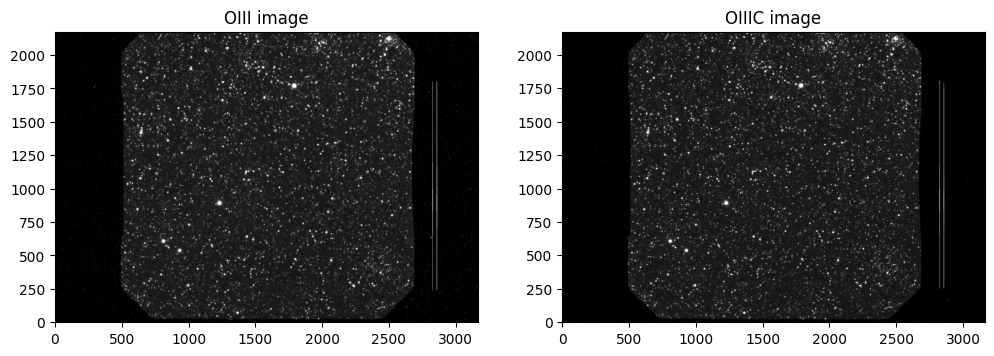

In [69]:
# plot image previews
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(oiii_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiii_image, 5), vmax=np.nanpercentile(oiii_image, 99.5))
ax1.set_title("OIII image")

ax2.imshow(oiiic_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiiic_image, 5), vmax=np.nanpercentile(oiiic_image, 99.5))
ax2.set_title("OIIIC image")

plt.show()

In [70]:
# identify sources in the images

# OIII stats
mean, median, std = sigma_clipped_stats(oiii_image)

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundness_range=(-0.2, 0.2))
sources = daofind(oiii_image - median)

# get 50 stars with the most flux
sources.sort("flux")
sources.reverse()
sources[:50]

id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
724,1230.7339288222915,889.3360159232959,0.2924032495377166,0.0038885262,-0.11665038350529353,81,18.963531,1116.842,-7.6199794,-5.540997931248763
489,811.2054256040692,604.5209644019868,0.3804044737351079,-0.014494867,0.10098500142086371,81,23.685776,950.9377,-7.44538,-6.27987166854863
423,932.7571452179785,534.8199931825619,0.4215424403400883,0.017209902,0.0868014005853623,81,20.279282,746.3878,-7.1824117,-6.113900728890641
1157,643.6512015351573,1416.2746261554662,0.4634524967697239,-0.03523817,0.06497808769366328,81,10.982344,379.21185,-6.447205,-5.418593391575591
34,1364.849469406094,69.28954887458866,0.47326103425804544,-0.04873896,0.09227796726752975,81,5.4746,179.5969,-5.6357474,-4.6862429244625
1402,1566.1992579915152,1677.8521898690724,0.46298205857643643,0.0047701765,0.12087372769831697,81,5.0745034,177.52426,-5.6231446,-4.5687352588270205
1727,2466.324054220412,1997.516436025767,0.46247027148259623,-0.009260361,0.13660341410949994,81,4.243157,151.2048,-5.448914,-4.359438238288715
523,1434.9423579593047,638.9442078597593,0.4556824631635074,-0.0126514165,0.06130173158086196,81,4.2442684,150.72946,-5.445495,-4.375474381084569
1774,1289.5428775467258,2047.943487029705,0.4625009047294786,-0.019199418,0.045439662493566214,81,4.123012,146.77242,-5.4166107,-4.329035078482274


 id      x_center           y_center         aperture_sum   
--- ------------------ ------------------ ------------------
  1 14.733928822291546 15.336015923295918 2088.4345942899904  id      x_center           y_center         aperture_sum   
--- ------------------ ------------------ ------------------
  1 14.733928822291546 15.336015923295918 3140.6452127475663


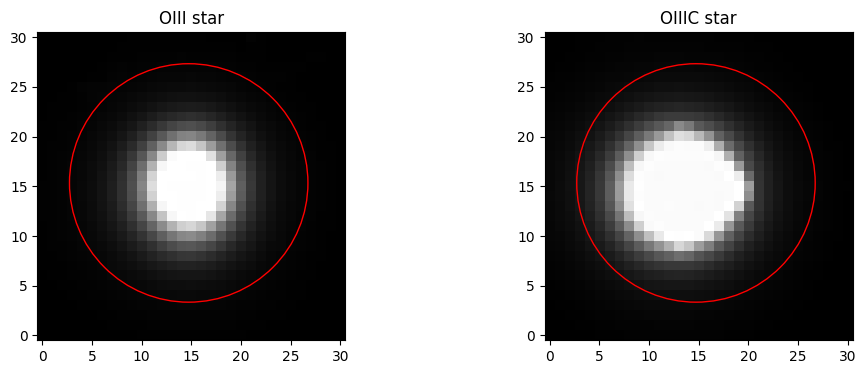

In [96]:
# cut out the detected stars and apply to both images





for star in sources[:1]:
    
    x = star["x_centroid"]
    y = star["y_centroid"]

    cutout_oiii = Cutout2D(oiii_image, (x, y), size=31)
    cutout_oiiic = Cutout2D(oiiic_image, (x, y), size=31)
    
    star_oiii = cutout_oiii.data
    star_oiiic = cutout_oiiic.data
    
    
    # oiii aperture drawing
    pos_oiii = cutout_oiii.input_position_cutout      # local cutout coords
    # pos_oiii = centroid_quadratic(star_oiii, fit_boxsize=7, search_boxsize=7)     # recentre the centroid
    aperture_oiii = CircularAperture(pos_oiii, r=12)
    
    pos_oiiic = cutout_oiiic.input_position_cutout     # local cutout coords
    # pos_oiiic = centroid_quadratic(star_oiiic, fit_boxsize=7, search_boxsize=10)     # recentre the centroid
    aperture_oiiic = CircularAperture(pos_oiiic, r=12)
    
    
    oiii_raw = aperture_photometry(star_oiii, aperture_oiii)
    oiiic_raw = aperture_photometry(star_oiiic, aperture_oiiic)


    print(oiii_raw, oiiic_raw)
   






# plot star previews
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
ax1.set_title("OIII star")

ax2.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
ax2.set_title("OIIIC star")

aperture_oiii.plot(ax=ax1, color="red")
aperture_oiiic.plot(ax=ax2, color="red")

plt.show()


In [72]:
# query individual star (maybe as a function)

In [73]:
# add star to database

In [74]:
# import gaia bp filter for scaling

In [75]:
# import stellar spectra for individual star

In [76]:
# import gmos filter

In [77]:
# integrate spectra within gmos filter

In [78]:
# plot results and line of best fit